# Часть 1. Проверка гипотезы в Python и составление аналитической записки

## Проверка гипотезы в Python

- Автор: Виктория Саватнеева
- Дата: 02.11.2025

## Цели и задачи проекта

<font color='#777778'>Основная цель проекта - провести самостоятельное A/B тестирование на данных по активности пользователей в разных городах, а также на других данных проверить корректность проведенного тестирования, проаналазировать результаты.

Задачи: провести предобработку данных и выяснить наличие дубликатов в них, определить их количество при обнаружении. Также нужно проверить гипотезу на имеющихся данных с помощью статистического теста и обосновать его результаты. 

Также на других данных необходимо провести оценку результатов A/B-теста и проанализировать полученные результаты. </font>

## Описание данных

<font color='#777778'>Данные таблицы участников тестов:
- user_id — идентификатор пользователя;
- group — группа пользователя;
- ab_test — название теста;
- device — устройство, с которого происходила регистрация
    
Данные таблицы, где собраны события 2020 года:
- user_id — идентификатор пользователя;
- event_dt — дата и время события;
- event_name — тип события;
- details — дополнительные данные о событии</font>

## Содержимое проекта

<font color='#777778'> Часть 1:
1. Загрузка данных и ознакомление с ними
2. Проверка гипотезы в Python
3. Аналитическая записка
    
Часть 2:
1. Описание целей исследования
2. Загрузка данных, оценка целостности
3. Оценка корректности проведения теста
4. Оценка результатов A/B тестирования
</font>

## 1. Загрузка данных и знакомство с ними

Загрузим данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


In [4]:
display(df.head(5))

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


Видим, что в данных нет пропусков, а тип данных соответствует значениям в таблице. Проверим данные на наличие дубликатов:

In [5]:
df.duplicated(subset='puid').sum()

244

В данных в столбце с идентификатором есть 244 дубликата, удалим их:

In [6]:
df = df.drop_duplicates(subset='puid', keep=False)

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуем статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

Проверим наличие выбросов в данных:

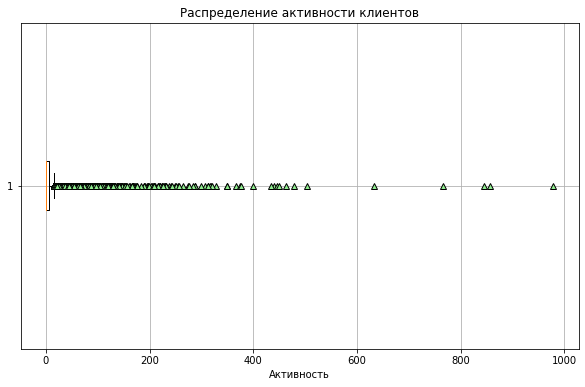

In [7]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    df['hours'], 
    vert=False,
    flierprops=dict(markerfacecolor='lightgreen', marker='^')
)

plt.title('Распределение активности клиентов')

plt.xlabel('Активность')

plt.grid(True)

plt.show()

В данных есть выбросы, которые могут повлиять на результат

Сравним размеры групп и их статистики:

In [8]:
group_sizes = df['city'].value_counts()
print(group_sizes)


Москва             5990
Санкт-Петербург    2306
Name: city, dtype: int64


Сравнивая размеры групп, можем заметить, что количество пользователей из СПб в 2,6 раз меньше, чем пользователей из Москвы, что делает группы неравноценными для сравнения между собой

In [9]:
from scipy.stats import mannwhitneyu

# Разделяем данные на две выборки по группам A и B
metric_a = df[
    (df.city == 'Санкт-Петербург')
]['hours']  #целевая метрика
metric_b = df[
(df.city == 'Москва')
]['hours']  #целевая метрика

alpha = 0.05
mw_test = mannwhitneyu(
    metric_a, # Выборка значений метрики для группы А
    metric_b, # Выборка значений метрики для группы B
    alternative='greater'
)
if mw_test.pvalue > alpha:
    print(f'pvalue={mw_test.pvalue} > {alpha}')
    print('Нулевая гипотеза находит подтверждение! Распределения метрики в группах A и B равны')
else:
    print(f'pvalue={mw_test.pvalue} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения! Распределения метрики в группах A и B различаются')

pvalue=0.4532273739367588 > 0.05
Нулевая гипотеза находит подтверждение! Распределения метрики в группах A и B равны


Исходя из результатов статистического теста, видим, что p-значение больше уровня значимости, следовательно у нас нет достаточных оснований отвергнуть нулевую гипотезу

## 3. Аналитическая записка
По результатам анализа данных подготовим аналитическую записку

Для проверки гипотезы был использован тест Манна-Уитни, так как в данных есть выбросы, их довольно много. Уровень значимости был выбран стандартный (0,05), так как не было дополнительных условий к этому параметру в ТЗ

В результате проведенного теста значение p_value (0,45) оказалось больше уровня статистической значимости, т.о. нулевая гипотеза о равенстве активности в двух городах находит подтверждение

Такой результат обусловлен разным количеством пользователей в двух группах: пользователей из СПб в 2,6 раз меньше, чем пользователей из Москвы. При сравнении такого количества пользователей статистически значимых различий в сравнении двух выборок нет, следовательно, если бы выборки были равны, то нулевая гипотеза не нашла бы подтврждения

----

# Часть 2. Анализ результатов A/B-тестирования

Теперь нужно проанализировать другие данные. Представим, что к нам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Задача — провести оценку результатов A/B-теста.

## 1. Опишем цели исследования.



Целью исследования является анализ корректности проведения теста, а также интерпретация полученных результатов

## 2. Загрузим данные, оценим их целостность.


In [10]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [11]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [12]:
display(participants.head(5))

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [13]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


In [14]:
display(events.head(5))

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


Видим, что в данных датасета `participants` нет пропусков, а названия столбцов соответствуют содержимому в них данных

В датасете `events` пропуски содержатся в столбце `details`, названия столбцов также соответствуют логике содержимого данных

## 3. По таблице `ab_test_participants` оценим корректность проведения теста:

   3\.1 Выделим пользователей, участвующих в тесте, и проверим:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

Проверим равномерность распределения пользователей по группам теста:

In [15]:
#Фильтруем пользователей группы А
gr_a = participants[(participants['group'] == 'A') & (participants['ab_test'] == 'interface_eu_test')]

#Фильтруем пользователей группы B
gr_b = participants[(participants['group'] == 'B') & (participants['ab_test'] == 'interface_eu_test')]

In [16]:
# Подсчёт уникальных пользователей для группы A
unique_users_group_a = gr_a['user_id'].nunique()

# Подсчёт уникальных пользователей для группы B
unique_users_group_b = gr_b['user_id'].nunique()

print(unique_users_group_a, unique_users_group_b)

5383 5467


Контрольные группы А и В равномерно распределены между собой по количеству пользователей, участвующих в эксперименте

Проверим, есть ли пересечение между пользователями в двух группах:

In [17]:
group_a = participants[(participants['group'] == 'A') & (participants['ab_test'] == 'interface_eu_test')]['user_id']
group_b = participants[(participants['group'] == 'B') & (participants['ab_test'] == 'interface_eu_test')]['user_id']

intersection = list(set(group_a) & set(group_b))
print(intersection) 

[]


Пользователей, участвующих в двух экспериментальных группах одновременно нет

3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

Отфильтруем датасет по регистрации и покупках пользователей:

In [18]:
events['event_name'].unique()

array(['End of Black Friday Ads Campaign', 'registration', 'product_page',
       'login', 'product_cart', 'purchase',
       'Start of Christmas&New Year Promo',
       'Start of CIS New Year Gift Lottery'], dtype=object)

In [19]:
events_filtred = events[(events['event_name'] == 'registration') | (events['event_name'] == 'purchase')]

In [20]:
display(events_filtred)

,user_id,event_dt,event_name,details
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
5,AA346F4D22148024,2020-12-01 00:01:46,registration,-2.0
6,7EF01D0E72AF449D,2020-12-01 00:02:06,registration,-5.0
7,9A6276AD14B14252,2020-12-01 00:02:20,registration,-2.0
8,9B186A3B1A995D36,2020-12-01 00:02:37,registration,-3.5
...,...,...,...,...
787273,CA617333EFAE4A10,2020-12-31 23:56:25,registration,-2.85
787277,10CAFD77114A4537,2020-12-31 23:56:56,registration,-4.07
787282,B77B2F4BCA134618,2020-12-31 23:58:23,registration,0.0
787284,B12AD1623E494FAD,2020-12-31 23:58:34,registration,-6.52


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [21]:
# Преобразуем столбец с датой события в формат datetime
events_filtred['event_dt'] = pd.to_datetime(events_filtred['event_dt'])

# Найдём дату регистрации для каждого пользователя
registration_dates = events_filtred[events_filtred['event_name'] == 'registration'].groupby('user_id')['event_dt'].min()

# Найдём дату покупки для каждого пользователя
purchase_dates = events_filtred[events_filtred['event_name'] == 'purchase'].groupby('user_id')['event_dt'].min()

# Присоединим даты регистрации к основному датафрейму
df_registration_events = events_filtred.merge(registration_dates, on='user_id', how='left', suffixes=('', '_registration'))

# Присоединим даты покупки к основному датафрейму
df_registration_events = df_registration_events.merge(purchase_dates, on='user_id', how='left', suffixes=('', '_purchase'))

display(df_registration_events)

/tmp/ipykernel_31/3245786426.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_filtred['event_dt'] = pd.to_datetime(events_filtred['event_dt'])


,user_id,event_dt,event_name,details,event_dt_registration,event_dt_purchase
0,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0,2020-12-01 00:00:11,2020-12-01 00:24:53
1,AA346F4D22148024,2020-12-01 00:01:46,registration,-2.0,2020-12-01 00:01:46,NaT
2,7EF01D0E72AF449D,2020-12-01 00:02:06,registration,-5.0,2020-12-01 00:02:06,NaT
3,9A6276AD14B14252,2020-12-01 00:02:20,registration,-2.0,2020-12-01 00:02:20,NaT
4,9B186A3B1A995D36,2020-12-01 00:02:37,registration,-3.5,2020-12-01 00:02:37,NaT
...,...,...,...,...,...,...
249014,CA617333EFAE4A10,2020-12-31 23:56:25,registration,-2.85,2020-12-31 23:56:25,NaT
249015,10CAFD77114A4537,2020-12-31 23:56:56,registration,-4.07,2020-12-31 23:56:56,NaT
249016,B77B2F4BCA134618,2020-12-31 23:58:23,registration,0.0,2020-12-31 23:58:23,NaT
249017,B12AD1623E494FAD,2020-12-31 23:58:34,registration,-6.52,2020-12-31 23:58:34,NaT


In [22]:
# Рассчитываем разницу между датой события и датой регистрации
df_registration_events['lifetime'] = (df_registration_events['event_dt_purchase'] - df_registration_events['event_dt_registration']).dt.days

# Оставляем только те события, которые были выполнены в течение первых семи дней
filtred_events = df_registration_events[df_registration_events['lifetime'] < 7]

display(filtred_events)

,user_id,event_dt,event_name,details,event_dt_registration,event_dt_purchase,lifetime
0,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0,2020-12-01 00:00:11,2020-12-01 00:24:53,0.0
5,099E67CE8BA24E60,2020-12-01 00:03:25,registration,-3.5,2020-12-01 00:03:25,2020-12-01 00:29:06,0.0
7,787935A6C58F412C,2020-12-01 00:03:34,registration,-0.5,2020-12-01 00:03:34,2020-12-01 01:06:44,0.0
9,8C65B5BD80CA2185,2020-12-01 00:04:10,registration,-2.5,2020-12-01 00:04:10,2020-12-01 02:12:57,0.0
13,DF15433470774F05,2020-12-01 00:05:23,registration,0.0,2020-12-01 00:05:23,2020-12-01 00:18:26,0.0
...,...,...,...,...,...,...,...
248959,8E609EEC2099D285,2020-12-31 23:26:43,purchase,4.49,2020-12-31 23:01:26,2020-12-31 23:26:43,0.0
248967,B17F683471A37EF2,2020-12-31 23:30:06,purchase,4.49,2020-12-31 23:22:37,2020-12-31 23:30:06,0.0
248992,ADDBAA58B87C6AF3,2020-12-31 23:44:53,purchase,4.49,2020-12-29 01:30:14,2020-12-31 23:44:53,2.0
248993,88B413C849BD4EF1,2020-12-31 23:45:01,registration,-2.85,2020-12-31 23:45:01,2020-12-31 23:53:13,0.0


In [25]:
filtred_events['lifetime'].unique()

array([0., 1., 3., 6., 5., 4., 2.])

Исходя из результатов расчета, видим, что время (лайфтайм) совершения события пользователем после регистрации иногда и составляло 0 дней, т.е. было совершено в день регистрации

Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [26]:
from statsmodels.stats.power import NormalIndPower

alpha = 0.05  
power = 0.8
beta = 1-power
p1 = 0.3
mde= 0.03
p2 = p1 + mde

power_analysis = NormalIndPower()
effect_size = (p2 - p1) / np.sqrt((p1*(1-p1) + p2*(1-p2))/2)

sample_size = power_analysis.solve_power(
        effect_size = effect_size,
        power = power,
        alpha = alpha,
        ratio = 1
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3759


Необходимый размер выборки для каждой группы для проведения анализа - 3759 пользователей. Сейчас в эксперименте задействованы около 5400 человек в каждой группе

- рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

Для того, чтобы рассчитать для каждой группы количество посетителей, сделавших покупку, объединим датафреймы `participants` и `filtred_events`

In [35]:
df_participants_events = participants.merge(filtred_events, on='user_id', how='left')

In [36]:
display(df_participants_events)

,user_id,group,ab_test,device,event_dt,event_name,details,event_dt_registration,event_dt_purchase,lifetime
0,0002CE61FF2C4011,B,interface_eu_test,Mac,NaT,NaN,NaN,NaT,NaT,NaN
1,001064FEAAB631A1,B,recommender_system_test,Android,NaT,NaN,NaN,NaT,NaT,NaN
2,001064FEAAB631A1,A,interface_eu_test,Android,NaT,NaN,NaN,NaT,NaT,NaN
3,0010A1C096941592,A,recommender_system_test,Android,2020-12-17 21:07:26,registration,0.0,2020-12-17 21:07:26,2020-12-21 21:12:18,4.0
4,0010A1C096941592,A,recommender_system_test,Android,2020-12-21 21:12:18,purchase,4.99,2020-12-17 21:07:26,2020-12-21 21:12:18,4.0
...,...,...,...,...,...,...,...,...,...,...
25370,FFE7FC140521F5F6,A,interface_eu_test,PC,2020-12-26 14:37:51,purchase,4.49,2020-12-23 09:10:16,2020-12-26 14:37:21,3.0
25371,FFEFC0E55C1CCD4F,A,interface_eu_test,PC,NaT,NaN,NaN,NaT,NaT,NaN
25372,FFF28D02B1EACBE1,B,recommender_system_test,PC,NaT,NaN,NaN,NaT,NaT,NaN
25373,FFF28D02B1EACBE1,B,interface_eu_test,PC,NaT,NaN,NaN,NaT,NaT,NaN


In [37]:
#Группируем данные по группам и считаем количество посетителей, сделавших покупку
group_purchase_count = df_participants_events[
    (df_participants_events['event_name'] == 'purchase') &
    (df_participants_events['ab_test'] == 'interface_eu_test')
].groupby('group')['user_id'].nunique()

#Считаем общее количество посетителей для каждой группы
total_visitors_count = df_participants_events[df_participants_events['ab_test'] == 'interface_eu_test'].groupby('group')['user_id'].nunique()

print("Количество посетителей, сделавших покупку по группам:")
print(group_purchase_count)
print("\nОбщее количество посетителей по группам:")
print(total_visitors_count)


Количество посетителей, сделавших покупку по группам:
group
A    1480
B    1600
Name: user_id, dtype: int64

Общее количество посетителей по группам:
group
A    5383
B    5467
Name: user_id, dtype: int64


В группе А всего 5383 пользователей, а совершивших покупку - 1480

В группе В всего 5467 пользователей, а совершивших покупку - 1600

Таким образом, предварительно конверсия зарегистрированных пользователей в покупателей увеличилась после проведения упрощения интерфейса

Проверим пересечения между группами А и В внутри `interface_eu_test`

In [42]:
group_A = df_participants_events[df_participants_events['group'] == 'A']['user_id'].unique()
group_B = df_participants_events[df_participants_events['group'] == 'B']['user_id'].unique()

intersection_AB = set(group_A).intersection(group_B)
print("Пересечение между группами A и B:", intersection_AB)

Пересечение между группами A и B: {'091AC977394578DA', '0DD2E54D87CFD4A4', '5438D422A6A53E0E', 'CB0B5021B1BE7403', '8C0E932FB144D00F', '06D2B163CB560FAC', 'FA86D8DFAD3ADADE', '1353B1C2F6E6AA4E', '3C46C1264F52F92C', 'DFE341550729F28E', '4F26C1C82B9EA0B5', '975744C6B0C12D72', 'E3048C1D75193226', '44F7F21118841F2D', '5650B53B91DC98BB', 'EC998D82E096033B', '8D406B3B500671BD', 'E65F1C4C712CDC41', 'F34D48681A35BD3B', '3D960D56A0E4E0C7', '4408C615880185FB', '98720595D29108E9', 'EEF5EFB2D5915CF1', 'F0A1C31A7211AC16', 'BBFD227B06D480C6', 'A412E4B7C71C0D94', 'CE264232AC9049B8', '1FA7A8399291885E', '19302754B5457163', '9FC882129DBDE625', '3FD750E6566CE5E3', 'B37F427F93BCA1E3', '9266418A9D2FA813', '2D7AF97EEB0056A5', '8C0361CB080810CA', 'BE52857ABCAD4C9B', '9F15AB8A7F968248', '3D264F3D953DBA67', '69E475C5708ABE56', 'B27B9689064C54C4', 'A847CBD3730F6D41', 'FF2174A1AA0EAD20', '4664BF4717549775', '11C52432A6F7FA6B', '535DC74493925CF8', 'C670F0DE6C790F3C', 'CE771EFC59ED44A5', 'F07BB43BAEF2AB42', '538F

Проверим пересечения внутри группы В между тестами `interface_eu_test` и `recommender_system_test`:

In [43]:
group_b_interface = df_participants_events[
    (df_participants_events['ab_test'] == 'interface_eu_test') & (df_participants_events['group'] == 'B')
]['user_id'].unique()

group_b_recommender = df_participants_events[
    (df_participants_events['ab_test'] == 'recommender_system_test') & (df_participants_events['group'] == 'B')
]['user_id'].unique()

intersection_b = set(group_b_interface).intersection(group_b_recommender)
print("Пересечение между группой B в тестах interface_eu_test и recommender_system_test:", intersection_b)


Пересечение между группой B в тестах interface_eu_test и recommender_system_test: {'EA8341F38EFFE04C', '53732758D90FB1E4', 'DD4352CDCF8C3D57', 'D1DFCE26FF3C713F', '902F92052587344F', 'BEF16764A13AEC34', '4B34A5BD1D1AEF0D', '63F5FC15B31DB5A6', '23E633E92EDCD195', 'C7750723906C925A', '067D05BD30F04F2E', 'BA9906DF9975512E', '6610064A4B2303D1', '7D8970118A695D48', '8FFA1D6F89AAEA40', 'FFF28D02B1EACBE1', 'C0924D3FF1BEAA05', '573EF5CB449265BE', 'DD9FB2652AE4ACBA', '1D831F7D0F539AFA', 'E391353FC3A4056D', 'B3059CB4FD2DE0FA', '0A0141A363E2E051', '1B52830A832D33F5', 'FEA0C585A53E7027', '430C998549E88DAE', 'A3D5BA3E276CD84C', 'AEB9B39AE54D3598', '14AEC962812EB706', 'BA98FD8F84C838C7', '84AAB026310D49C4', '9918D1C354A1383A', '88FB1EDF3E249223', '649CE5D5A38BFA8B', '0FBF679EA1340786', 'AE49EDDFB9DABE03', 'C4F3A9D7BB596E6E', 'EE25BC8FA059151D', 'C33D8C1C81C7AA23', '8FF91E21E27A330D', '59D9BD2A3172D3F4', 'BF1EB8E6FA3F19B8', '5B1F39B5D751B669', '1AD9F88DA92AC4E5', '928364C4C9F13FA8', 'FC2DA0D7EF375B27

Видим, что есть пересечения как между группами А и В внутри `interface_eu_test`, так и внутри группы В между тестами `interface_eu_test` и `recommender_system_test`. Исключим этих пользователей из контрольных групп:

In [45]:
# Исключаем пользователей из пересечения из исходного датафрейма
df_participants_events = df_participants_events[~df_participants_events['user_id'].isin(intersection_AB)]

In [46]:
# Исключаем пользователей из пересечения из исходного датафрейма
df_participants_events = df_participants_events[~df_participants_events['user_id'].isin(intersection_b)]

## 4. Проведем оценку результатов A/B-тестирования:

- Проверим изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

Нулевая гипотеза (H0): новый интерфейс не оказывает значимого влияния на увеличение конверсии зарегистрированных пользователей  в покупателей по сравнению с другим интерфейсом

Альтернативная гипотеза (H1): новый интерфейс повышает долю успешных сессий по сравнению с текущим интерфейсом.

Проверим изменение конверсии с помощью Z-теста пропорций:

In [54]:
from statsmodels.stats.proportion import proportions_ztest

n_a = total_visitors_count['A']
n_b = total_visitors_count['B']
m_a = group_purchase_count['A']
m_b = group_purchase_count['B']

p_a, p_b = m_a/n_a, m_b/n_b # посчитайте доли успехов для каждой группы: A и B

if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10): # проверьте предпосылку о достаточном количестве данных
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

alpha =  0.05 # уровень значимости

stat_ztest, p_value_ztest = proportions_ztest( # проведите Z-тест пропорций
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller'
)

print(f'pvalue={p_value_ztest}') # выведите полученное p-value 

if p_value_ztest > alpha:
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')
    
if p_value_ztest < alpha:
    if p_a > p_b:
        text_interpretation = 'сократилась'
    elif p_a < p_b:
        text_interpretation = 'увеличилась'
else:
    text_interpretation = 'не изменилась'

print(f'При упрощении интерфейса конверсия зарегистрированных пользователей в покупателей у тестовой группы {text_interpretation}')

diff = p_b - p_a  # разница в долях успехов между группами B и A
threshold = 0.03  # пороговое значение в 3 процентных пункта

if diff >= threshold:
    print("Конверсия увеличилась как минимум на 3 процентных пункта.")
else:
    print("Увеличение конверсии менее чем на 3 процентных пункта.")
    
# Рассчитываем конверсии
conversion_a = m_a / n_a
conversion_b = m_b / n_b

# Рассчитываем разницу
difference = conversion_b - conversion_a

print(f"Конверсия в группе A: {conversion_a}")
print(f"Конверсия в группе B: {conversion_b}")
print(f"Разница в конверсиях: {difference}")


Предпосылка о достаточном количестве данных выполняется!
pvalue=0.020306993983065475
Нулевая гипотеза не находит подтверждения!
При упрощении интерфейса конверсия зарегистрированных пользователей в покупателей у тестовой группы увеличилась
Увеличение конверсии менее чем на 3 процентных пункта.
Конверсия в группе A: 0.27493962474456624
Конверсия в группе B: 0.29266508139747577
Разница в конверсиях: 0.017725456652909533


По проведенной оценке результатов А/В тестирования видим, что значение `p-value=0,02`, что позволяет нам отвергнуть нулевую гипотезу и принять альтернативную об увеличении конверсии зарегистрированных пользователей в покупателей

Был достигнут ожидаемый эффект в увеличении конверсии, однако, гипотеза о ее увеличении на 3 процентных пункта не находит подтверждения, так как увеличение конверсии составило 1,77%.

Также в результате анализа проведения А/В тестирования была определена рекомендуемая и фактическая выборка пользователей в группах. Фактическая составила около 5400 пользователей, участвующих в эксперименте, рекомендуемая - около 3800 пользователей. Пересечений пользователей между группами не было обнаружено в результате анализа.

В результате расчета лайфтайма было выявлено, что для некоторых пользователей он составил 0 дней, т.е. после регистрации сразу была совершена покупка